In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("train.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.shape

(891, 12)

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [14]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [15]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [16]:
df['Pclass'].unique()

array([3, 1, 2])

In [17]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [18]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [19]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [20]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [21]:
df['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

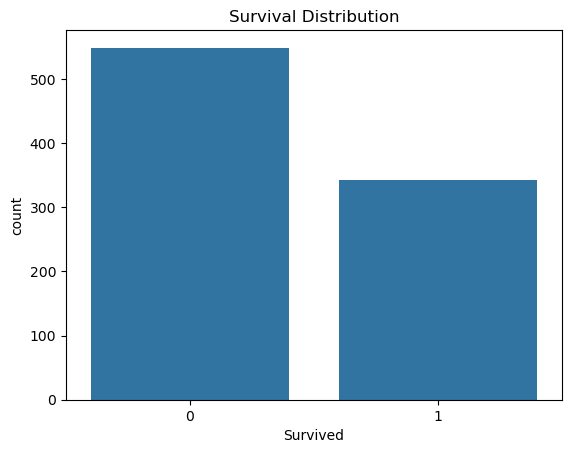

In [22]:
sns.countplot(data=df, x='Survived')
plt.title("Survival Distribution")
plt.show()

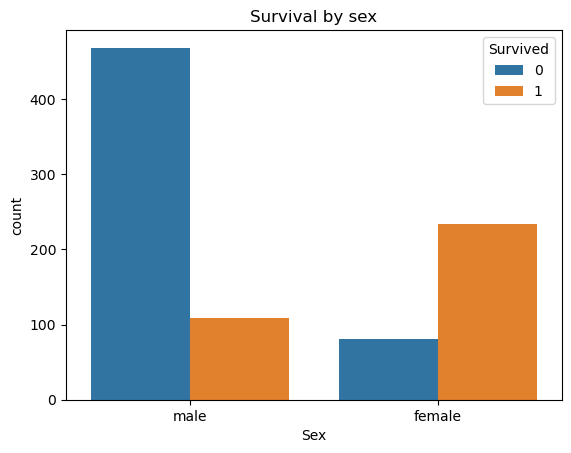

In [23]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival by sex")
plt.show()

In [24]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [25]:
pd.crosstab(df['Sex'], df['Survived'], normalize='index')*100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


Text(0.5, 1.0, 'Survived by Passanger Class')

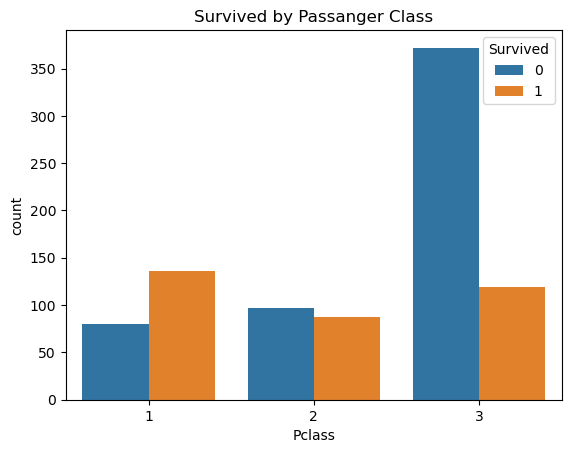

In [26]:
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title("Survived by Passanger Class")


In [27]:
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [28]:
pd.crosstab(df['Pclass'], df['Survived'], normalize='index')*100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


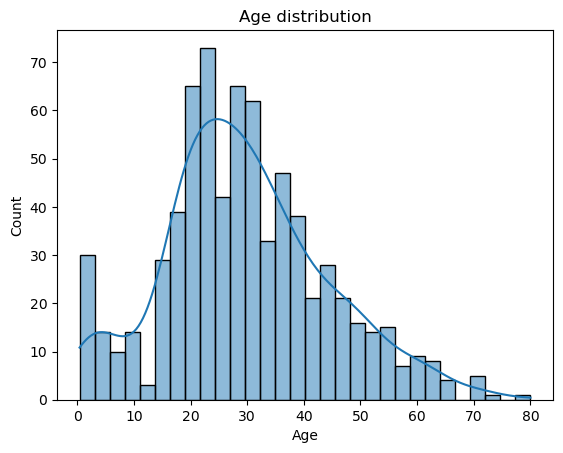

In [29]:
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age distribution")
plt.show()

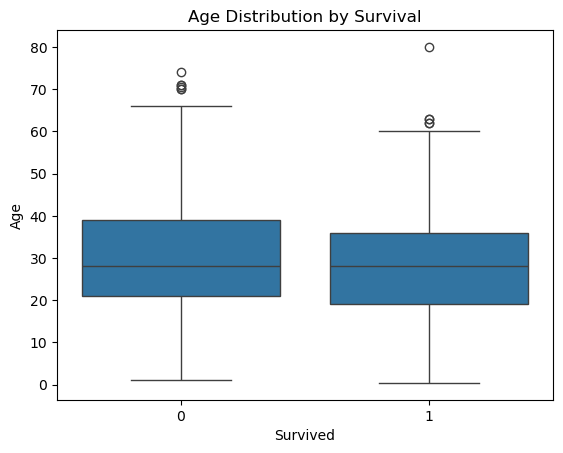

In [30]:
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Age Distribution by Survival")
plt.show()

In [31]:
pd.crosstab(
    [df["Sex"], df["Pclass"]],
    df["Survived"]
)

Survived         0   1
Sex    Pclass         
female 1         3  91
       2         6  70
       3        72  72
male   1        77  45
       2        91  17
       3       300  47

In [32]:
pd.crosstab(
    [df["Sex"], df["Pclass"]],
    df["Survived"],
    normalize="index"
) * 100

Survived               0          1
Sex    Pclass                      
female 1        3.191489  96.808511
       2        7.894737  92.105263
       3       50.000000  50.000000
male   1       63.114754  36.885246
       2       84.259259  15.740741
       3       86.455331  13.544669

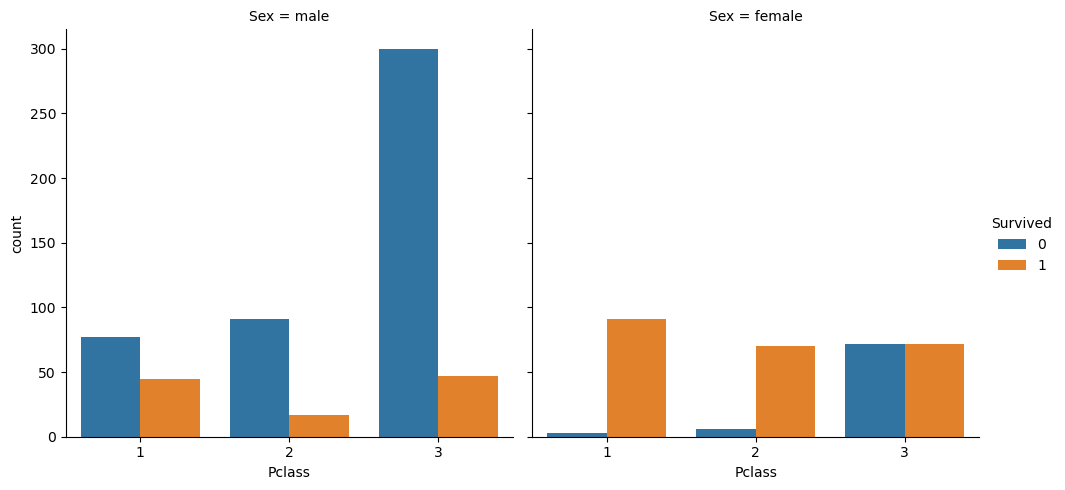

In [33]:
sns.catplot(
    data=df,
    x="Pclass",
    hue="Survived",
    col="Sex",
    kind="count"
)

plt.show()

In [34]:
bins = [0, 12, 17, 29, 49, 64, float("inf")]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior",
    "Elderly"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["AgeGroup"] = df["AgeGroup"].cat.add_categories(["Unknown"])
df["AgeGroup"] = df["AgeGroup"].fillna("Unknown")

In [35]:
df["AgeGroup"].value_counts(dropna=False)

AgeGroup
Young Adult    271
Adult          256
Unknown        177
Child           69
Senior          63
Teen            44
Elderly         11
Name: count, dtype: int64

In [36]:
pd.crosstab(
    df["AgeGroup"],
    df["Survived"],
    normalize="index"
) * 100

Survived,0,1
AgeGroup,,
Child,42.028986,57.971014
Teen,52.272727,47.727273
Young Adult,64.944649,35.055351
Adult,58.203125,41.796875
Senior,58.730159,41.269841
Elderly,90.909091,9.090909
Unknown,70.621469,29.378531


In [37]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [38]:
df[["SibSp", "Parch", "FamilySize"]].head(10)

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


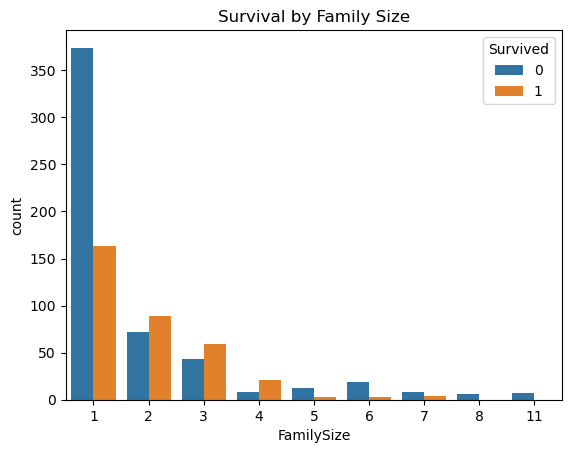

In [39]:
sns.countplot(
    data=df,
    x="FamilySize",
    hue="Survived"
)

plt.title("Survival by Family Size")
plt.show()

In [40]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [41]:
df["IsAlone"].value_counts()

IsAlone
1    537
0    354
Name: count, dtype: int64

In [42]:
pd.crosstab(
    df["IsAlone"],
    df["Survived"],
    normalize="index"
) * 100

Survived,0,1
IsAlone,,
0,49.435028,50.564972
1,69.646182,30.353818


In [43]:
df["Title"] = df["Name"].str.extract(
    r",\s*([^.]*)\."
)[0].str.strip()

In [44]:
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [45]:
pd.crosstab(
    df["Title"],
    df["Survived"],
    normalize="index"
) * 100

Survived,0,1
Title,,
Capt,100.000000,0.000000
Col,50.000000,50.000000
Don,100.000000,0.000000
Dr,57.142857,42.857143
Jonkheer,100.000000,0.000000
Lady,0.000000,100.000000
Major,50.000000,50.000000
Master,42.500000,57.500000
Miss,30.219780,69.780220


In [46]:
df["CabinDeck"] = df["Cabin"].str[0]

In [47]:
df["CabinDeck"] = df["CabinDeck"].fillna("Unknown")

In [48]:
df["CabinDeck"].value_counts()

CabinDeck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [49]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
AgeGroup         0
FamilySize       0
IsAlone          0
Title            0
CabinDeck        0
dtype: int64

In [50]:
df["CabinDeck"] = df["Cabin"].str[0]

df["CabinDeck"] = df["CabinDeck"].fillna("Unknown")

In [51]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [52]:
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [53]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [54]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup',
       'FamilySize', 'IsAlone', 'Title', 'CabinDeck'],
      dtype='object')

In [55]:
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [56]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

df["Title"] = df["Title"].apply(
    lambda x: x if x in common_titles else "Rare"
)

In [57]:
df["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [58]:
df["CabinDeck"] = df["Cabin"].str[0]

In [59]:
df["CabinDeck"] = df["CabinDeck"].fillna("Unknown")

In [60]:
df["CabinDeck"].value_counts()

CabinDeck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [61]:
df["Embarked"].value_counts(dropna=False)

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [62]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title",
    "CabinDeck"
]

In [63]:
X = df[features]

In [64]:
y = df["Survived"]

In [65]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,CabinDeck
0,3,male,22.0,1,0,7.2500,S,2,0,Mr,Unknown
1,1,female,38.0,1,0,71.2833,C,2,0,Mrs,C
2,3,female,26.0,0,0,7.9250,S,1,1,Miss,Unknown
3,1,female,35.0,1,0,53.1000,S,2,0,Mrs,C
4,3,male,35.0,0,0,8.0500,S,1,1,Mr,Unknown


In [66]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [67]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 11)
y shape: (891,)


In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [70]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 11)
X_test: (179, 11)
y_train: (712,)
y_test: (179,)


In [71]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

In [72]:
categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "CabinDeck"
]

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [74]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [75]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [76]:
from sklearn.compose import ColumnTransformer

In [77]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [78]:
from sklearn.linear_model import LogisticRegression

In [79]:
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [80]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
y_pred = logistic_model.predict(X_test)

In [82]:
y_pred[:20]

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1])

In [83]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.iloc[:20].values,
    "Predicted": y_pred[:20]
})

comparison

,Actual,Predicted
0,0,0
1,0,0
2,1,0
3,0,0
4,1,1
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [84]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8435754189944135


In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88       110
           1       0.83      0.75      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [86]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[99 11]
 [17 52]]


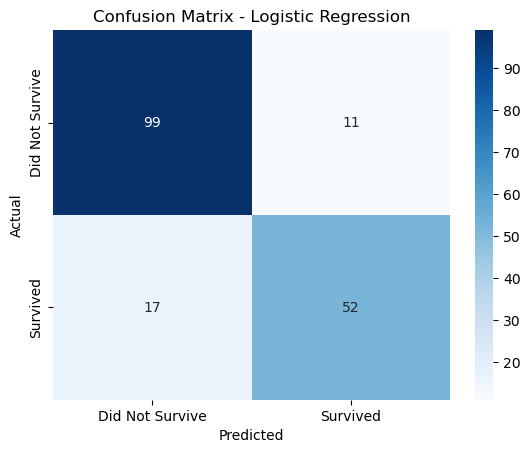

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [88]:
from sklearn.metrics import roc_auc_score

y_prob = logistic_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8711462450592885


In [89]:
from sklearn.tree import DecisionTreeClassifier

In [90]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [91]:
decision_tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [92]:
y_pred_dt = decision_tree_model.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.7821229050279329


In [94]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       110
           1       0.73      0.68      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



In [95]:
from sklearn.metrics import roc_auc_score

y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC-AUC:", roc_auc_dt)

Decision Tree ROC-AUC: 0.7598155467720685


In [96]:
print("Model Comparison")
print("----------------------------")
print(f"Logistic Regression Accuracy : {accuracy:.4f}")
print(f"Logistic Regression ROC-AUC  : {roc_auc:.4f}")
print()
print(f"Decision Tree Accuracy       : {accuracy_dt:.4f}")
print(f"Decision Tree ROC-AUC        : {roc_auc_dt:.4f}")

Model Comparison
----------------------------
Logistic Regression Accuracy : 0.8436
Logistic Regression ROC-AUC  : 0.8711

Decision Tree Accuracy       : 0.7821
Decision Tree ROC-AUC        : 0.7598


In [97]:
from sklearn.ensemble import RandomForestClassifier

In [98]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [99]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [100]:
y_pred_rf = random_forest_model.predict(X_test)

In [101]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8044692737430168


In [102]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [103]:
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.827733860342556


In [104]:
print("Model Comparison")
print("----------------------------")

print(f"Logistic Regression Accuracy : {accuracy:.4f}")
print(f"Logistic Regression ROC-AUC  : {roc_auc:.4f}")

print(f"Decision Tree Accuracy       : {accuracy_dt:.4f}")
print(f"Decision Tree ROC-AUC        : {roc_auc_dt:.4f}")

print(f"Random Forest Accuracy       : {accuracy_rf:.4f}")
print(f"Random Forest ROC-AUC        : {roc_auc_rf:.4f}")

Model Comparison
----------------------------
Logistic Regression Accuracy : 0.8436
Logistic Regression ROC-AUC  : 0.8711
Decision Tree Accuracy       : 0.7821
Decision Tree ROC-AUC        : 0.7598
Random Forest Accuracy       : 0.8045
Random Forest ROC-AUC        : 0.8277


In [105]:
from sklearn.neighbors import KNeighborsClassifier

In [106]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]
)

In [107]:
knn_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [108]:
y_pred_knn = knn_model.predict(X_test)

In [109]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.8212290502793296


In [110]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



In [111]:
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

print("KNN ROC-AUC:", roc_auc_knn)

KNN ROC-AUC: 0.8467061923583663


In [112]:
print("Model Comparison")
print("----------------------------")

print(f"Logistic Regression Accuracy : {accuracy:.4f}")
print(f"Logistic Regression ROC-AUC  : {roc_auc:.4f}")

print(f"Decision Tree Accuracy       : {accuracy_dt:.4f}")
print(f"Decision Tree ROC-AUC        : {roc_auc_dt:.4f}")

print(f"Random Forest Accuracy       : {accuracy_rf:.4f}")
print(f"Random Forest ROC-AUC        : {roc_auc_rf:.4f}")

print(f"KNN Accuracy                : {accuracy_knn:.4f}")
print(f"KNN ROC-AUC                 : {roc_auc_knn:.4f}")

Model Comparison
----------------------------
Logistic Regression Accuracy : 0.8436
Logistic Regression ROC-AUC  : 0.8711
Decision Tree Accuracy       : 0.7821
Decision Tree ROC-AUC        : 0.7598
Random Forest Accuracy       : 0.8045
Random Forest ROC-AUC        : 0.8277
KNN Accuracy                : 0.8212
KNN ROC-AUC                 : 0.8467


In [113]:
from sklearn.ensemble import GradientBoostingClassifier

In [114]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

In [115]:
gradient_boosting_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [116]:
y_pred_gb = gradient_boosting_model.predict(X_test)

In [117]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 0.8100558659217877


In [118]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [119]:
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting ROC-AUC:", roc_auc_gb)

Gradient Boosting ROC-AUC: 0.8459156785243742


In [120]:
print("Model Comparison")
print("----------------------------")

print(f"Logistic Regression Accuracy : {accuracy:.4f}")
print(f"Logistic Regression ROC-AUC  : {roc_auc:.4f}")

print(f"Decision Tree Accuracy       : {accuracy_dt:.4f}")
print(f"Decision Tree ROC-AUC        : {roc_auc_dt:.4f}")

print(f"Random Forest Accuracy       : {accuracy_rf:.4f}")
print(f"Random Forest ROC-AUC        : {roc_auc_rf:.4f}")

print(f"KNN Accuracy                 : {accuracy_knn:.4f}")
print(f"KNN ROC-AUC                  : {roc_auc_knn:.4f}")

print(f"Gradient Boosting Accuracy   : {accuracy_gb:.4f}")
print(f"Gradient Boosting ROC-AUC    : {roc_auc_gb:.4f}")

Model Comparison
----------------------------
Logistic Regression Accuracy : 0.8436
Logistic Regression ROC-AUC  : 0.8711
Decision Tree Accuracy       : 0.7821
Decision Tree ROC-AUC        : 0.7598
Random Forest Accuracy       : 0.8045
Random Forest ROC-AUC        : 0.8277
KNN Accuracy                 : 0.8212
KNN ROC-AUC                  : 0.8467
Gradient Boosting Accuracy   : 0.8101
Gradient Boosting ROC-AUC    : 0.8459


In [121]:
from sklearn.model_selection import cross_val_score

In [122]:
cv_lr = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:", cv_lr)
print("Mean Accuracy:", cv_lr.mean())
print("Standard Deviation:", cv_lr.std())

Logistic Regression CV Scores: [0.77622378 0.81118881 0.84507042 0.83802817 0.82394366]
Mean Accuracy: 0.8188909681867429
Standard Deviation: 0.024318464147231194


In [123]:
cv_dt = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Decision Tree CV Scores:", cv_dt)
print("Mean Accuracy:", cv_dt.mean())
print("Standard Deviation:", cv_dt.std())

Decision Tree CV Scores: [0.75524476 0.67832168 0.75352113 0.81690141 0.79577465]
Mean Accuracy: 0.759952723333005
Standard Deviation: 0.04744158707935906


In [124]:
cv_rf = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Scores:", cv_rf)
print("Mean Accuracy:", cv_rf.mean())
print("Standard Deviation:", cv_rf.std())

Random Forest CV Scores: [0.76923077 0.72027972 0.81690141 0.85211268 0.79577465]
Mean Accuracy: 0.7908598443809712
Standard Deviation: 0.044505277329673944


In [125]:
cv_knn = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("KNN CV Scores:", cv_knn)
print("Mean Accuracy:", cv_knn.mean())
print("Standard Deviation:", cv_knn.std())

KNN CV Scores: [0.74125874 0.79020979 0.82394366 0.81690141 0.83802817]
Mean Accuracy: 0.8020683541810303
Standard Deviation: 0.03414700993046249


In [126]:
cv_gb = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Gradient Boosting CV Scores:", cv_gb)
print("Mean Accuracy:", cv_gb.mean())
print("Standard Deviation:", cv_gb.std())

Gradient Boosting CV Scores: [0.78321678 0.79020979 0.85915493 0.85915493 0.83098592]
Mean Accuracy: 0.8245444696148923
Standard Deviation: 0.032631604237344194


In [127]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Gradient Boosting"
    ],
    "Mean CV Accuracy": [
        cv_lr.mean(),
        cv_dt.mean(),
        cv_rf.mean(),
        cv_knn.mean(),
        cv_gb.mean()
    ],
    "Std Dev": [
        cv_lr.std(),
        cv_dt.std(),
        cv_rf.std(),
        cv_knn.std(),
        cv_gb.std()
    ]
})

cv_results

,Model,Mean CV Accuracy,Std Dev
0,Logistic Regression,0.818891,0.024318
1,Decision Tree,0.759953,0.047442
2,Random Forest,0.790860,0.044505
3,KNN,0.802068,0.034147
4,Gradient Boosting,0.824544,0.032632


In [128]:
cv_lr_auc = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Logistic Regression Mean ROC-AUC:", cv_lr_auc.mean())

Logistic Regression Mean ROC-AUC: 0.8666489872602725


In [129]:
cv_dt_auc = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Decision Tree Mean ROC-AUC:", cv_dt_auc.mean())
print("Decision Tree Std Dev:", cv_dt_auc.std())

Decision Tree Mean ROC-AUC: 0.7554515109295673
Decision Tree Std Dev: 0.047728417951170554


In [130]:
cv_rf_auc = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Random Forest Mean ROC-AUC:", cv_rf_auc.mean())
print("Random Forest Std Dev:", cv_rf_auc.std())

Random Forest Mean ROC-AUC: 0.8488896673105136
Random Forest Std Dev: 0.03228005556767849


In [131]:
cv_knn_auc = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("KNN Mean ROC-AUC:", cv_knn_auc.mean())
print("KNN Std Dev:", cv_knn_auc.std())

KNN Mean ROC-AUC: 0.8444554347022999
KNN Std Dev: 0.026482885443896393


In [132]:
cv_gb_auc = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Gradient Boosting Mean ROC-AUC:", cv_gb_auc.mean())
print("Gradient Boosting Std Dev:", cv_gb_auc.std())

Gradient Boosting Mean ROC-AUC: 0.8791611649409455
Gradient Boosting Std Dev: 0.022440537643931033


In [133]:
cv_complete_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Gradient Boosting"
    ],
    
    "Mean CV Accuracy": [
        cv_lr.mean(),
        cv_dt.mean(),
        cv_rf.mean(),
        cv_knn.mean(),
        cv_gb.mean()
    ],
    
    "Accuracy Std": [
        cv_lr.std(),
        cv_dt.std(),
        cv_rf.std(),
        cv_knn.std(),
        cv_gb.std()
    ],
    
    "Mean CV ROC-AUC": [
        cv_lr_auc.mean(),
        cv_dt_auc.mean(),
        cv_rf_auc.mean(),
        cv_knn_auc.mean(),
        cv_gb_auc.mean()
    ],
    
    "ROC-AUC Std": [
        cv_lr_auc.std(),
        cv_dt_auc.std(),
        cv_rf_auc.std(),
        cv_knn_auc.std(),
        cv_gb_auc.std()
    ]
})

cv_complete_results

,Model,Mean CV Accuracy,Accuracy Std,Mean CV ROC-AUC,ROC-AUC Std
0,Logistic Regression,0.818891,0.024318,0.866649,0.017438
1,Decision Tree,0.759953,0.047442,0.755452,0.047728
2,Random Forest,0.790860,0.044505,0.848890,0.032280
3,KNN,0.802068,0.034147,0.844455,0.026483
4,Gradient Boosting,0.824544,0.032632,0.879161,0.022441


In [134]:
basic_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

In [135]:
X_basic = df[basic_features]

In [136]:
X_basic.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [137]:
X_basic_train, X_basic_test, y_basic_train, y_basic_test = train_test_split(
    X_basic,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [138]:
basic_numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

In [139]:
basic_categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

In [140]:
basic_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [141]:
basic_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [142]:
basic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", basic_numeric_transformer, basic_numeric_features),
        ("cat", basic_categorical_transformer, basic_categorical_features)
    ]
)

In [143]:
gb_basic_model = Pipeline(
    steps=[
        ("preprocessor", basic_preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

In [144]:
basic_cv_accuracy = cross_val_score(
    gb_basic_model,
    X_basic_train,
    y_basic_train,
    cv=5,
    scoring="accuracy"
)

print("Basic Features CV Scores:", basic_cv_accuracy)
print("Mean CV Accuracy:", basic_cv_accuracy.mean())
print("Std Dev:", basic_cv_accuracy.std())

Basic Features CV Scores: [0.77622378 0.76223776 0.85915493 0.84507042 0.83802817]
Mean CV Accuracy: 0.8161430119176597
Std Dev: 0.03915380331048667


In [145]:
basic_cv_auc = cross_val_score(
    gb_basic_model,
    X_basic_train,
    y_basic_train,
    cv=5,
    scoring="roc_auc"
)

print("Basic Features ROC-AUC Scores:", basic_cv_auc)
print("Mean CV ROC-AUC:", basic_cv_auc.mean())
print("Std Dev:", basic_cv_auc.std())

Basic Features ROC-AUC Scores: [0.84917355 0.83192149 0.91776385 0.90046296 0.88646886]
Mean CV ROC-AUC: 0.877158140970837
Std Dev: 0.03196285121066184


In [146]:
experiment2_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

In [147]:
X_exp2 = df[experiment2_features]

In [148]:
X_exp2_train, X_exp2_test, y_exp2_train, y_exp2_test = train_test_split(
    X_exp2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [149]:
exp2_numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

In [150]:
exp2_categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

In [151]:
exp2_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [152]:
exp2_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [153]:
exp2_preprocessor = ColumnTransformer(
    transformers=[
        ("num", exp2_numeric_transformer, exp2_numeric_features),
        ("cat", exp2_categorical_transformer, exp2_categorical_features)
    ]
)

In [154]:
gb_exp2_model = Pipeline(
    steps=[
        ("preprocessor", exp2_preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

In [155]:
exp2_cv_accuracy = cross_val_score(
    gb_exp2_model,
    X_exp2_train,
    y_exp2_train,
    cv=5,
    scoring="accuracy"
)

print("Experiment 2 Accuracy Scores:", exp2_cv_accuracy)
print("Mean CV Accuracy:", exp2_cv_accuracy.mean())
print("Std Dev:", exp2_cv_accuracy.std())

Experiment 2 Accuracy Scores: [0.79020979 0.78321678 0.86619718 0.82394366 0.85211268]
Mean CV Accuracy: 0.8231360189106667
Std Dev: 0.03277878802737432


In [156]:
exp2_cv_auc = cross_val_score(
    gb_exp2_model,
    X_exp2_train,
    y_exp2_train,
    cv=5,
    scoring="roc_auc"
)

print("Experiment 2 ROC-AUC Scores:", exp2_cv_auc)
print("Mean CV ROC-AUC:", exp2_cv_auc.mean())
print("Std Dev:", exp2_cv_auc.std())

Experiment 2 ROC-AUC Scores: [0.84772727 0.8267562  0.91765935 0.9023569  0.88909933]
Mean CV ROC-AUC: 0.876719810434544
Std Dev: 0.03412766840399903


In [157]:
print("Feature Experiment Comparison")
print("--------------------------------")

print(f"Basic Features Accuracy : {basic_cv_accuracy.mean():.4f}")
print(f"Basic Features ROC-AUC  : {basic_cv_auc.mean():.4f}")

print()

print(f"Basic + Family Features Accuracy : {exp2_cv_accuracy.mean():.4f}")
print(f"Basic + Family Features ROC-AUC  : {exp2_cv_auc.mean():.4f}")

Feature Experiment Comparison
--------------------------------
Basic Features Accuracy : 0.8161
Basic Features ROC-AUC  : 0.8772

Basic + Family Features Accuracy : 0.8231
Basic + Family Features ROC-AUC  : 0.8767


In [158]:
experiment3_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title"
]

In [159]:
X_exp3 = df[experiment3_features]

In [160]:
X_exp3.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,3,male,22.0,1,0,7.2500,S,2,0,Mr
1,1,female,38.0,1,0,71.2833,C,2,0,Mrs
2,3,female,26.0,0,0,7.9250,S,1,1,Miss
3,1,female,35.0,1,0,53.1000,S,2,0,Mrs
4,3,male,35.0,0,0,8.0500,S,1,1,Mr


In [161]:
X_exp3_train, X_exp3_test, y_exp3_train, y_exp3_test = train_test_split(
    X_exp3,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [162]:
exp3_numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

In [163]:
exp3_categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title"
]

In [164]:
exp3_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [165]:
exp3_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [166]:
exp3_preprocessor = ColumnTransformer(
    transformers=[
        ("num", exp3_numeric_transformer, exp3_numeric_features),
        ("cat", exp3_categorical_transformer, exp3_categorical_features)
    ]
)

In [167]:
gb_exp3_model = Pipeline(
    steps=[
        ("preprocessor", exp3_preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

In [168]:
exp3_cv_accuracy = cross_val_score(
    gb_exp3_model,
    X_exp3_train,
    y_exp3_train,
    cv=5,
    scoring="accuracy"
)

print("Experiment 3 Accuracy Scores:", exp3_cv_accuracy)
print("Mean CV Accuracy:", exp3_cv_accuracy.mean())
print("Std Dev:", exp3_cv_accuracy.std())

Experiment 3 Accuracy Scores: [0.79020979 0.77622378 0.83802817 0.81690141 0.85211268]
Mean CV Accuracy: 0.8146951639909386
Std Dev: 0.028386433566493084


In [169]:
exp3_cv_auc = cross_val_score(
    gb_exp3_model,
    X_exp3_train,
    y_exp3_train,
    cv=5,
    scoring="roc_auc"
)

print("Experiment 3 ROC-AUC Scores:", exp3_cv_auc)
print("Mean CV ROC-AUC:", exp3_cv_auc.mean())
print("Std Dev:", exp3_cv_auc.std())

Experiment 3 ROC-AUC Scores: [0.85661157 0.83409091 0.9107628  0.89225589 0.88141835]
Mean CV ROC-AUC: 0.8750279044362117
Std Dev: 0.02694298834440385


In [170]:
print("Feature Experiment Comparison")
print("--------------------------------")

print(f"Basic Features Accuracy              : {basic_cv_accuracy.mean():.4f}")
print(f"Basic Features ROC-AUC               : {basic_cv_auc.mean():.4f}")

print(f"Basic + Family Features Accuracy     : {exp2_cv_accuracy.mean():.4f}")
print(f"Basic + Family Features ROC-AUC      : {exp2_cv_auc.mean():.4f}")

print(f"Basic + Family + Title Accuracy      : {exp3_cv_accuracy.mean():.4f}")
print(f"Basic + Family + Title ROC-AUC       : {exp3_cv_auc.mean():.4f}")

Feature Experiment Comparison
--------------------------------
Basic Features Accuracy              : 0.8161
Basic Features ROC-AUC               : 0.8772
Basic + Family Features Accuracy     : 0.8231
Basic + Family Features ROC-AUC      : 0.8767
Basic + Family + Title Accuracy      : 0.8147
Basic + Family + Title ROC-AUC       : 0.8750


In [171]:
experiment4_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title",
    "CabinDeck"
]

In [172]:
X_exp4 = df[experiment4_features]

In [173]:
X_exp4.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,CabinDeck
0,3,male,22.0,1,0,7.2500,S,2,0,Mr,Unknown
1,1,female,38.0,1,0,71.2833,C,2,0,Mrs,C
2,3,female,26.0,0,0,7.9250,S,1,1,Miss,Unknown
3,1,female,35.0,1,0,53.1000,S,2,0,Mrs,C
4,3,male,35.0,0,0,8.0500,S,1,1,Mr,Unknown


In [174]:
X_exp4_train, X_exp4_test, y_exp4_train, y_exp4_test = train_test_split(
    X_exp4,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [175]:
exp4_numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

In [176]:
exp4_categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "CabinDeck"
]

In [177]:
exp4_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [178]:
exp4_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [179]:
exp4_preprocessor = ColumnTransformer(
    transformers=[
        ("num", exp4_numeric_transformer, exp4_numeric_features),
        ("cat", exp4_categorical_transformer, exp4_categorical_features)
    ]
)

In [180]:
gb_exp4_model = Pipeline(
    steps=[
        ("preprocessor", exp4_preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

In [181]:
exp4_cv_accuracy = cross_val_score(
    gb_exp4_model,
    X_exp4_train,
    y_exp4_train,
    cv=5,
    scoring="accuracy"
)

print("Experiment 4 Accuracy Scores:", exp4_cv_accuracy)
print("Mean CV Accuracy:", exp4_cv_accuracy.mean())
print("Std Dev:", exp4_cv_accuracy.std())

Experiment 4 Accuracy Scores: [0.78321678 0.79020979 0.85915493 0.85915493 0.83098592]
Mean CV Accuracy: 0.8245444696148923
Std Dev: 0.032631604237344194


In [182]:
exp4_cv_auc = cross_val_score(
    gb_exp4_model,
    X_exp4_train,
    y_exp4_train,
    cv=5,
    scoring="roc_auc"
)

print("Experiment 4 ROC-AUC Scores:", exp4_cv_auc)
print("Mean CV ROC-AUC:", exp4_cv_auc.mean())
print("Std Dev:", exp4_cv_auc.std())

Experiment 4 ROC-AUC Scores: [0.85640496 0.85072314 0.9061651  0.90046296 0.88204966]
Mean CV ROC-AUC: 0.8791611649409455
Std Dev: 0.022440537643931033


In [183]:
print("Feature Experiment Comparison")
print("--------------------------------")

print(f"Basic Features Accuracy          : {basic_cv_accuracy.mean():.4f}")
print(f"Basic Features ROC-AUC           : {basic_cv_auc.mean():.4f}")

print(f"Basic + Family Accuracy          : {exp2_cv_accuracy.mean():.4f}")
print(f"Basic + Family ROC-AUC           : {exp2_cv_auc.mean():.4f}")

print(f"Basic + Family + Title Accuracy  : {exp3_cv_accuracy.mean():.4f}")
print(f"Basic + Family + Title ROC-AUC   : {exp3_cv_auc.mean():.4f}")

print(f"All Features Accuracy            : {exp4_cv_accuracy.mean():.4f}")
print(f"All Features ROC-AUC             : {exp4_cv_auc.mean():.4f}")

Feature Experiment Comparison
--------------------------------
Basic Features Accuracy          : 0.8161
Basic Features ROC-AUC           : 0.8772
Basic + Family Accuracy          : 0.8231
Basic + Family ROC-AUC           : 0.8767
Basic + Family + Title Accuracy  : 0.8147
Basic + Family + Title ROC-AUC   : 0.8750
All Features Accuracy            : 0.8245
All Features ROC-AUC             : 0.8792


In [184]:
from sklearn.model_selection import GridSearchCV

In [185]:
param_grid = {
    "classifier__n_estimators": [50, 100, 150],
    "classifier__learning_rate": [0.05, 0.1, 0.2],
    "classifier__max_depth": [2, 3, 4],
    "classifier__min_samples_split": [2, 5]
}

In [186]:
grid_search = GridSearchCV(
    estimator=gb_exp4_model,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [187]:
grid_search.fit(X_exp4_train, y_exp4_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__learning_rate': [0.05, 0.1, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [50, 100, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [188]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [189]:
print("Best CV ROC-AUC:", grid_search.best_score_)

Best CV ROC-AUC: 0.8838647182377588


In [190]:
best_gb_model = grid_search.best_estimator_

In [191]:
y_pred_tuned = best_gb_model.predict(X_exp4_test)

In [192]:
tuned_accuracy = accuracy_score(
    y_exp4_test,
    y_pred_tuned
)

print("Tuned Gradient Boosting Accuracy:", tuned_accuracy)

Tuned Gradient Boosting Accuracy: 0.7877094972067039


In [193]:
print(classification_report(
    y_exp4_test,
    y_pred_tuned
))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       110
           1       0.75      0.68      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



In [194]:
y_prob_tuned = best_gb_model.predict_proba(
    X_exp4_test
)[:, 1]

tuned_roc_auc = roc_auc_score(
    y_exp4_test,
    y_prob_tuned
)

print("Tuned Gradient Boosting ROC-AUC:", tuned_roc_auc)

Tuned Gradient Boosting ROC-AUC: 0.844532279314888


In [198]:
print("Gradient Boosting Comparison")
print("--------------------------------")

print(f"Before Tuning CV Accuracy : {exp4_cv_accuracy.mean():.4f}")
print(f"Before Tuning CV ROC-AUC  : {exp4_cv_auc.mean():.4f}")

print()

print(f"After Tuning CV ROC-AUC   : {grid_search.best_score_:.4f}")

print()

print(f"Tuned Test Accuracy       : {tuned_accuracy:.4f}")
print(f"Tuned Test ROC-AUC        : {tuned_roc_auc:.4f}")

Gradient Boosting Comparison
--------------------------------
Before Tuning CV Accuracy : 0.8245
Before Tuning CV ROC-AUC  : 0.8792

After Tuning CV ROC-AUC   : 0.8839

Tuned Test Accuracy       : 0.7877
Tuned Test ROC-AUC        : 0.8445


In [200]:
gb_exp4_model.fit(
    X_exp4_train,
    y_exp4_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [202]:
y_pred_exp4 = gb_exp4_model.predict(X_exp4_test)

exp4_test_accuracy = accuracy_score(
    y_exp4_test,
    y_pred_exp4
)

y_prob_exp4 = gb_exp4_model.predict_proba(
    X_exp4_test
)[:, 1]

exp4_test_roc_auc = roc_auc_score(
    y_exp4_test,
    y_prob_exp4
)

print("Original Gradient Boosting")
print("--------------------------")
print(f"Test Accuracy : {exp4_test_accuracy:.4f}")
print(f"Test ROC-AUC  : {exp4_test_roc_auc:.4f}")

Original Gradient Boosting
--------------------------
Test Accuracy : 0.8101
Test ROC-AUC  : 0.8459


In [203]:
from sklearn.metrics import confusion_matrix

cm_gb = confusion_matrix(
    y_exp4_test,
    y_pred_exp4
)

print(cm_gb)

[[98 12]
 [22 47]]


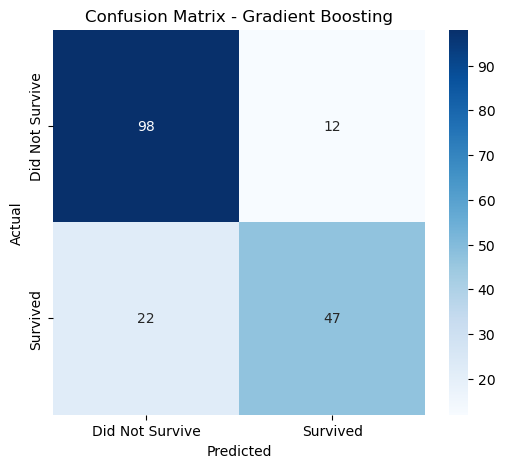

In [204]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")

plt.show()

In [205]:
gb_classifier = gb_exp4_model.named_steps["classifier"]

In [206]:
feature_names = gb_exp4_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print(feature_names)

['num__Age' 'num__SibSp' 'num__Parch' 'num__Fare' 'num__FamilySize'
 'num__IsAlone' 'cat__Pclass_1' 'cat__Pclass_2' 'cat__Pclass_3'
 'cat__Sex_female' 'cat__Sex_male' 'cat__Embarked_C' 'cat__Embarked_Q'
 'cat__Embarked_S' 'cat__Title_Master' 'cat__Title_Miss' 'cat__Title_Mr'
 'cat__Title_Mrs' 'cat__Title_Rare' 'cat__CabinDeck_A' 'cat__CabinDeck_B'
 'cat__CabinDeck_C' 'cat__CabinDeck_D' 'cat__CabinDeck_E'
 'cat__CabinDeck_F' 'cat__CabinDeck_G' 'cat__CabinDeck_T'
 'cat__CabinDeck_Unknown']


In [207]:
importances = gb_classifier.feature_importances_

In [208]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [209]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [210]:
feature_importance_df

,Feature,Importance
16,cat__Title_Mr,0.395044
3,num__Fare,0.145453
8,cat__Pclass_3,0.109845
0,num__Age,0.095039
4,num__FamilySize,0.056483
9,cat__Sex_female,0.037014
27,cat__CabinDeck_Unknown,0.036976
10,cat__Sex_male,0.035253
18,cat__Title_Rare,0.030795
13,cat__Embarked_S,0.015045


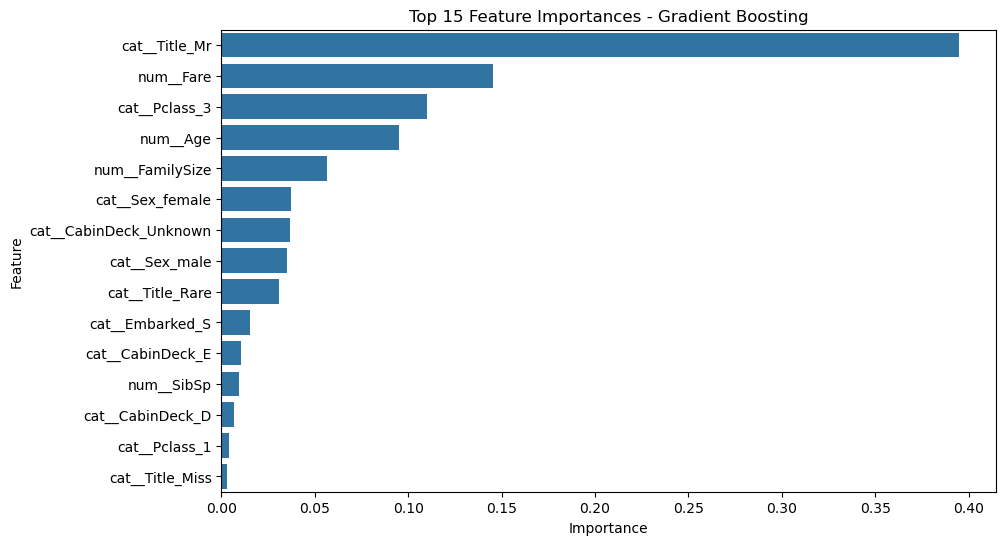

In [211]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [213]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],

    "CV Accuracy": [
        cv_lr.mean(),
        cv_dt.mean(),
        cv_rf.mean(),
        cv_knn.mean(),
        cv_gb.mean(),
        np.nan
    ],

    "CV ROC-AUC": [
        cv_lr_auc.mean(),
        cv_dt_auc.mean(),
        cv_rf_auc.mean(),
        cv_knn_auc.mean(),
        cv_gb_auc.mean(),
        grid_search.best_score_
    ],

    "Test Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf,
        accuracy_knn,
        exp4_test_accuracy,
        tuned_accuracy
    ],

    "Test ROC-AUC": [
        roc_auc,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_knn,
        exp4_test_roc_auc,
        tuned_roc_auc
    ]
})

final_comparison

,Model,CV Accuracy,CV ROC-AUC,Test Accuracy,Test ROC-AUC
0,Logistic Regression,0.818891,0.866649,0.843575,0.871146
1,Decision Tree,0.759953,0.755452,0.782123,0.759816
2,Random Forest,0.790860,0.848890,0.804469,0.827734
3,KNN,0.802068,0.844455,0.821229,0.846706
4,Gradient Boosting,0.824544,0.879161,0.810056,0.845916
5,Tuned Gradient Boosting,NaN,0.883865,0.787709,0.844532


In [214]:
final_comparison.round(4)

,Model,CV Accuracy,CV ROC-AUC,Test Accuracy,Test ROC-AUC
0,Logistic Regression,0.8189,0.8666,0.8436,0.8711
1,Decision Tree,0.7600,0.7555,0.7821,0.7598
2,Random Forest,0.7909,0.8489,0.8045,0.8277
3,KNN,0.8021,0.8445,0.8212,0.8467
4,Gradient Boosting,0.8245,0.8792,0.8101,0.8459
5,Tuned Gradient Boosting,NaN,0.8839,0.7877,0.8445


In [215]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_exp4_model = Pipeline(
    steps=[
        ("preprocessor", exp4_preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

In [216]:
lr_exp4_cv_accuracy = cross_val_score(
    lr_exp4_model,
    X_exp4_train,
    y_exp4_train,
    cv=5,
    scoring="accuracy"
)

lr_exp4_cv_auc = cross_val_score(
    lr_exp4_model,
    X_exp4_train,
    y_exp4_train,
    cv=5,
    scoring="roc_auc"
)

print("Logistic Regression EXP4")
print("------------------------")
print("CV Accuracy Scores:", lr_exp4_cv_accuracy)
print("Mean CV Accuracy:", lr_exp4_cv_accuracy.mean())
print("Accuracy Std:", lr_exp4_cv_accuracy.std())

print()

print("CV ROC-AUC Scores:", lr_exp4_cv_auc)
print("Mean CV ROC-AUC:", lr_exp4_cv_auc.mean())
print("ROC-AUC Std:", lr_exp4_cv_auc.std())

Logistic Regression EXP4
------------------------
CV Accuracy Scores: [0.77622378 0.81118881 0.84507042 0.83802817 0.82394366]
Mean CV Accuracy: 0.8188909681867429
Accuracy Std: 0.024318464147231194

CV ROC-AUC Scores: [0.83481405 0.8714876  0.87168234 0.88804714 0.8672138 ]
Mean CV ROC-AUC: 0.8666489872602725
ROC-AUC Std: 0.017437947035639292


In [217]:
gb_exp4_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [218]:
gb_exp4_cv_accuracy = cross_val_score(
    gb_exp4_model,
    X_exp4_train,
    y_exp4_train,
    cv=5,
    scoring="accuracy"
)

gb_exp4_cv_auc = cross_val_score(
    gb_exp4_model,
    X_exp4_train,
    y_exp4_train,
    cv=5,
    scoring="roc_auc"
)

print("Gradient Boosting EXP4")
print("---------------------")
print("CV Accuracy Scores:", gb_exp4_cv_accuracy)
print("Mean CV Accuracy:", gb_exp4_cv_accuracy.mean())
print("Accuracy Std:", gb_exp4_cv_accuracy.std())

print()

print("CV ROC-AUC Scores:", gb_exp4_cv_auc)
print("Mean CV ROC-AUC:", gb_exp4_cv_auc.mean())
print("ROC-AUC Std:", gb_exp4_cv_auc.std())

Gradient Boosting EXP4
---------------------
CV Accuracy Scores: [0.78321678 0.79020979 0.85915493 0.85915493 0.83098592]
Mean CV Accuracy: 0.8245444696148923
Accuracy Std: 0.032631604237344194

CV ROC-AUC Scores: [0.85640496 0.85072314 0.9061651  0.90046296 0.88204966]
Mean CV ROC-AUC: 0.8791611649409455
ROC-AUC Std: 0.022440537643931033


In [219]:
final_model_cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],
    
    "CV Accuracy": [
        lr_exp4_cv_accuracy.mean(),
        gb_exp4_cv_accuracy.mean()
    ],
    
    "Accuracy Std": [
        lr_exp4_cv_accuracy.std(),
        gb_exp4_cv_accuracy.std()
    ],
    
    "CV ROC-AUC": [
        lr_exp4_cv_auc.mean(),
        gb_exp4_cv_auc.mean()
    ],
    
    "ROC-AUC Std": [
        lr_exp4_cv_auc.std(),
        gb_exp4_cv_auc.std()
    ]
})

final_model_cv_comparison.round(4)

,Model,CV Accuracy,Accuracy Std,CV ROC-AUC,ROC-AUC Std
0,Logistic Regression,0.8189,0.0243,0.8666,0.0174
1,Gradient Boosting,0.8245,0.0326,0.8792,0.0224


In [220]:
X_exp4_test
y_exp4_test

565    0
160    0
553    1
860    0
241    1
      ..
880    1
91     0
883    0
473    1
637    0
Name: Survived, Length: 179, dtype: int64

In [221]:
final_model = gb_exp4_model

final_model.fit(
    X_exp4_train,
    y_exp4_train
)

print("Final model trained successfully.")

Final model trained successfully.


In [222]:
y_pred_final = final_model.predict(X_exp4_test)

y_prob_final = final_model.predict_proba(
    X_exp4_test
)[:, 1]

In [223]:
y_pred_final

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [224]:
y_prob_final

array([0.08999232, 0.11109014, 0.13335411, 0.07748323, 0.55925257,
       0.47231884, 0.82964107, 0.82358549, 0.67763097, 0.09913713,
       0.16898599, 0.11943562, 0.45035407, 0.14543638, 0.1165528 ,
       0.15962053, 0.06563272, 0.09695888, 0.03109114, 0.83536836,
       0.09695888, 0.88059776, 0.14580813, 0.47231884, 0.08695735,
       0.94460929, 0.31950536, 0.25126736, 0.2263551 , 0.11955213,
       0.10856287, 0.91991547, 0.60583149, 0.16064842, 0.3267139 ,
       0.791969  , 0.3267139 , 0.09219708, 0.16898599, 0.83788577,
       0.61240279, 0.96633345, 0.11995979, 0.83788577, 0.82916791,
       0.14065367, 0.09405951, 0.38883612, 0.91816027, 0.7808236 ,
       0.92167973, 0.39132656, 0.83695023, 0.09008837, 0.67996604,
       0.09695888, 0.09034251, 0.88983498, 0.59577765, 0.38883498,
       0.57239763, 0.8468831 , 0.14323707, 0.04962677, 0.45410399,
       0.47115602, 0.96395077, 0.10535699, 0.4201667 , 0.08778613,
       0.96362498, 0.13667235, 0.7843209 , 0.95708138, 0.10096

In [225]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

final_accuracy = accuracy_score(
    y_exp4_test,
    y_pred_final
)

final_roc_auc = roc_auc_score(
    y_exp4_test,
    y_prob_final
)

print("FINAL MODEL PERFORMANCE")
print("-----------------------")
print(f"Test Accuracy : {final_accuracy:.4f}")
print(f"Test ROC-AUC  : {final_roc_auc:.4f}")

FINAL MODEL PERFORMANCE
-----------------------
Test Accuracy : 0.8101
Test ROC-AUC  : 0.8459


In [226]:
print("FINAL MODEL CLASSIFICATION REPORT")
print("----------------------------------")

print(
    classification_report(
        y_exp4_test,
        y_pred_final
    )
)

FINAL MODEL CLASSIFICATION REPORT
----------------------------------
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [227]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_final = confusion_matrix(
    y_exp4_test,
    y_pred_final
)

print(cm_final)

[[98 12]
 [22 47]]


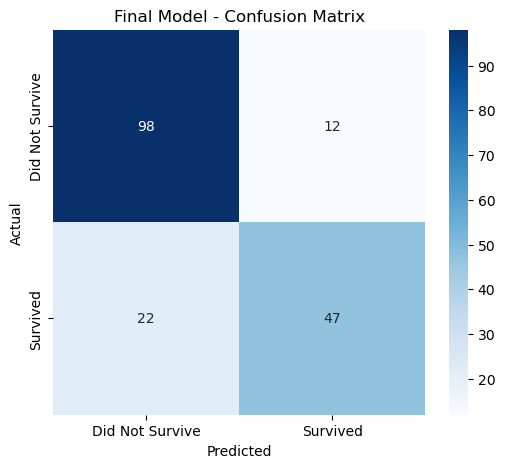

In [228]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model - Confusion Matrix")

plt.show()

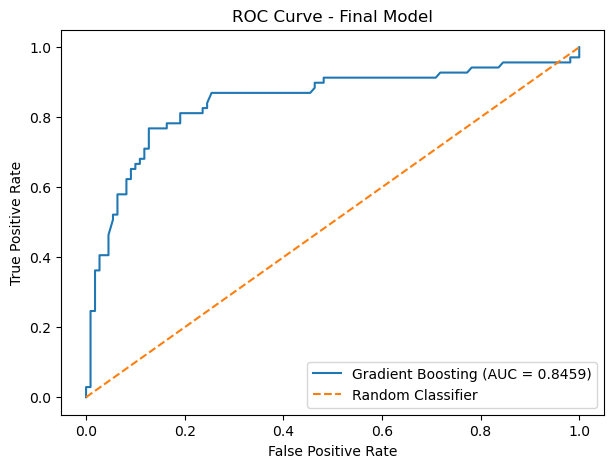

In [229]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_exp4_test,
    y_prob_final
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting (AUC = {final_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")

plt.legend()
plt.show()

In [230]:
import joblib

joblib.dump(
    final_model,
    "titanic_final_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [231]:
import os

print(os.path.exists("titanic_final_model.pkl"))

True


In [232]:
print(
    f"Model size: {os.path.getsize('titanic_final_model.pkl') / 1024:.2f} KB"
)

Model size: 134.84 KB


In [233]:
loaded_model = joblib.load(
    "titanic_final_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [234]:
test_prediction = loaded_model.predict(X_exp4_test)

print(test_prediction[:10])

[0 0 0 0 1 0 1 1 1 0]


In [235]:
loaded_accuracy = accuracy_score(
    y_exp4_test,
    test_prediction
)

print("Loaded Model Accuracy:", loaded_accuracy)

Loaded Model Accuracy: 0.8100558659217877


In [236]:
loaded_model.predict(X_exp4_test)

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [238]:
new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": ["male"],
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": ["S"],
    "FamilySize": [1],
    "IsAlone": [1],
    "Title": ["Mr"],
    "CabinDeck": ["Unknown"]
})

new_passenger

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,CabinDeck
0,3,male,25,0,0,7.25,S,1,1,Mr,Unknown


In [239]:
prediction = loaded_model.predict(new_passenger)

print("Prediction:", prediction[0])

Prediction: 0


In [240]:
probability = loaded_model.predict_proba(
    new_passenger
)

print(probability)

[[0.92345169 0.07654831]]


In [241]:
prediction = loaded_model.predict(new_passenger)[0]

survival_probability = loaded_model.predict_proba(
    new_passenger
)[0][1]

if prediction == 1:
    result = "Survived"
else:
    result = "Did Not Survive"

print("Prediction:", result)
print(f"Survival Probability: {survival_probability * 100:.2f}%")

Prediction: Did Not Survive
Survival Probability: 7.65%


In [242]:
def predict_survival(
    pclass,
    sex,
    age,
    sibsp,
    parch,
    fare,
    embarked,
    family_size,
    is_alone,
    title,
    cabin_deck
):
    
    passenger = pd.DataFrame({
        "Pclass": [pclass],
        "Sex": [sex],
        "Age": [age],
        "SibSp": [sibsp],
        "Parch": [parch],
        "Fare": [fare],
        "Embarked": [embarked],
        "FamilySize": [family_size],
        "IsAlone": [is_alone],
        "Title": [title],
        "CabinDeck": [cabin_deck]
    })

    prediction = loaded_model.predict(passenger)[0]

    probability = loaded_model.predict_proba(
        passenger
    )[0][1]

    if prediction == 1:
        result = "Survived"
    else:
        result = "Did Not Survive"

    return result, probability

In [243]:
result, probability = predict_survival(
    pclass=3,
    sex="male",
    age=25,
    sibsp=0,
    parch=0,
    fare=7.25,
    embarked="S",
    family_size=1,
    is_alone=1,
    title="Mr",
    cabin_deck="Unknown"
)

print("Prediction:", result)
print(f"Survival Probability: {probability * 100:.2f}%")

Prediction: Did Not Survive
Survival Probability: 7.65%
